going to get looking at some data

In [1]:
import pandas as pd
import numpy as np

big_data_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\2015-2025jSPXoptions.csv"

big_data = pd.read_csv(big_data_filepath)



In [2]:
# Inspect data structure
print("Dataset shape:", big_data.shape)
print("\nColumn names and types:")
print(big_data.info())
print("\nFirst few rows:")
print(big_data.head(5))
print("\nBasic statistics:")
print(big_data.describe())
print("\nData types:")
print(big_data.dtypes)
print("\nMissing values:")
print(big_data.isnull().sum())

Dataset shape: (42225530, 23)

Column names and types:
<class 'pandas.DataFrame'>
RangeIndex: 42225530 entries, 0 to 42225529
Data columns (total 23 columns):
 #   Column            Dtype  
---  ------            -----  
 0   secid             int64  
 1   date              str    
 2   symbol            str    
 3   exdate            str    
 4   cp_flag           str    
 5   strike_price      int64  
 6   best_bid          float64
 7   best_offer        float64
 8   volume            int64  
 9   open_interest     int64  
 10  impl_volatility   float64
 11  delta             float64
 12  gamma             float64
 13  vega              float64
 14  theta             float64
 15  optionid          int64  
 16  forward_price     float64
 17  expiry_indicator  str    
 18  index_flag        int64  
 19  issue_type        str    
 20  industry_group    float64
 21  issuer            str    
 22  exercise_style    str    
dtypes: float64(9), int64(6), str(8)
memory usage: 7.2 GB
None

Fi

In [3]:
columns_to_keep = ["secid", "date", "exdate", "cp_flag", "strike_price", "best_bid", "best_offer",
                    "optionid", "exercise_style", "delta", "vega", "gamma", "impl_volatility"]

filtered_data = big_data[columns_to_keep]
# Rename strike_price to K and divide by 1000
filtered_data = filtered_data.rename(columns={'strike_price': 'K'})
filtered_data['K'] = filtered_data['K'] / 1000

print(filtered_data.head(5))

#about equal number of calls and puts
#only european options

    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  02/01/2015  17/01/2015       C   100.0    1956.4      1959.6   
1  108105  02/01/2015  17/01/2015       C  1000.0    1056.7      1059.9   
2  108105  02/01/2015  17/01/2015       C  1025.0    1031.7      1034.9   
3  108105  02/01/2015  17/01/2015       C  1050.0    1006.7      1009.8   
4  108105  02/01/2015  17/01/2015       C  1075.0     981.7       984.8   

    optionid exercise_style     delta      vega     gamma  impl_volatility  
0  101234071              E       NaN       NaN       NaN              NaN  
1  101234072              E  0.999103  1.179546  0.000006         1.222229  
2  101234073              E  0.999083  1.204660  0.000006         1.181493  
3  101234074              E  0.999391  0.808892  0.000005         1.092237  
4  101234075              E  0.999382  0.820990  0.000005         1.054338  


In [4]:
# Convert date column to datetime format (dd/mm/yyyy)
filtered_data['date'] = pd.to_datetime(filtered_data['date'], format='%d/%m/%Y')
filtered_data['exdate'] = pd.to_datetime(filtered_data['exdate'], format='%d/%m/%Y')

# Filter data to only include dates between 02/16/2015 and 01/07/2021
cutoff_date_start = pd.to_datetime('2015-10-16')
cutoff_date_end = pd.to_datetime('2021-07-01')
filtered_data = filtered_data[(filtered_data['date'] >= cutoff_date_start) & (filtered_data['date'] < cutoff_date_end)]

print(f"Dataset shape after date filter: {filtered_data.shape}")
print(f"\nDate range: {filtered_data['date'].min()} to {filtered_data['date'].max()}")
print(f"\nFirst few rows:")
print(filtered_data.head())

Dataset shape after date filter: (18194288, 13)

Date range: 2015-10-16 00:00:00 to 2021-06-30 00:00:00

First few rows:
          secid       date     exdate cp_flag       K  best_bid  best_offer  \
1561744  108105 2015-10-16 2015-11-20       C  1000.0    1025.3      1030.0   
1561745  108105 2015-10-16 2015-11-20       C  1025.0    1000.4      1005.0   
1561746  108105 2015-10-16 2015-11-20       C  1050.0     975.4       980.0   
1561747  108105 2015-10-16 2015-11-20       C  1075.0     950.4       955.1   
1561748  108105 2015-10-16 2015-11-20       C  1100.0     925.4       930.1   

          optionid exercise_style     delta      vega     gamma  \
1561744  108485570              E  0.996078  2.218131  0.000007   
1561745  108485571              E  0.995777  2.784215  0.000009   
1561746  108485572              E  0.995758  2.818352  0.000010   
1561747  108485573              E  0.995439  3.404782  0.000012   
1561748  108485574              E  0.995409  3.459122  0.000013   

 

In [5]:
# Load SPX price data
spx_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\S&P 500 Historical Data 2015-2022.csv"  # Update filename if needed

spx_data = pd.read_csv(spx_filepath)

# Convert SPX date column to datetime format (mm/dd/yyyy)
spx_data['Date'] = pd.to_datetime(spx_data['Date'], format='%m/%d/%Y')

# Convert both date columns to date only (removing time component) for proper merging
# First ensure filtered_data['date'] is datetime before converting
if not pd.api.types.is_datetime64_any_dtype(filtered_data['date']):
    filtered_data['date'] = pd.to_datetime(filtered_data['date'])
    
filtered_data['date'] = filtered_data['date'].dt.date
filtered_data['exdate'] = filtered_data['exdate'].dt.date
spx_data['Date'] = spx_data['Date'].dt.date

print(spx_data.head())

# Merge filtered_data with spx_data on date columns
filtered_data = filtered_data.merge(spx_data[['Date', 'Price']], 
                                    left_on='date', 
                                    right_on='Date', 
                                    how='left')

# Rename 'Price' to 'S' and drop the duplicate 'Date' column
filtered_data = filtered_data.rename(columns={'Price': 'S'})
filtered_data = filtered_data.drop(columns=['Date'])



# Remove duplicate S columns, keeping only the first one
s_columns = [col for col in filtered_data.columns if col == 'S']
if len(s_columns) > 1:
    # Get all columns and remove duplicates
    filtered_data = filtered_data.loc[:, ~filtered_data.columns.duplicated(keep='first')]
    print("Removed duplicate columns")

print("Merge complete!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"\nFirst few rows:")
print(filtered_data.head())

         Date    Price      Open      High       Low  Vol. Change %
0  2025-10-03  6715.79  6,722.14  6,750.87  6,705.67   NaN    0.01%
1  2025-10-02  6715.35  6,731.31  6,731.94  6,693.23   NaN    0.06%
2  2025-10-01  6711.20  6,664.92  6,718.48  6,656.20   NaN    0.34%
3  2025-09-30  6688.46  6,656.19  6,691.25  6,641.00   NaN    0.41%
4  2025-09-29  6661.21  6,661.58  6,677.31  6,644.49   NaN    0.26%
Merge complete!
Filtered data shape: (18194288, 14)

First few rows:
    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  2015-10-16  2015-11-20       C  1000.0    1025.3      1030.0   
1  108105  2015-10-16  2015-11-20       C  1025.0    1000.4      1005.0   
2  108105  2015-10-16  2015-11-20       C  1050.0     975.4       980.0   
3  108105  2015-10-16  2015-11-20       C  1075.0     950.4       955.1   
4  108105  2015-10-16  2015-11-20       C  1100.0     925.4       930.1   

    optionid exercise_style     delta      vega     gamma  impl_volatili

In [6]:
vix_filepath = r"C:\Users\samib\OneDrive - Imperial College London\Imperial\Education\Year 4\Masters Project\Code\MastersProject\Data\Full_VIX_History.csv"  # Update filename if needed

vix_data = pd.read_csv(vix_filepath)

# Convert VIX date column to datetime format (mm/dd/yyyy)
vix_data['DATE'] = pd.to_datetime(vix_data['DATE'], format='%m/%d/%Y')

# Convert DATE to date only (removing time component) to match filtered_data['date']
vix_data['DATE'] = vix_data['DATE'].dt.date


print(vix_data.head())

# Merge filtered_data with vix_data on date columns
filtered_data = filtered_data.merge(vix_data[['DATE', 'CLOSE']], 
                                    left_on='date', 
                                    right_on='DATE', 
                                    how='left')

# Rename 'CLOSE' to 'sigma' and drop the duplicate 'DATE' column
filtered_data = filtered_data.rename(columns={'CLOSE': 'sigma'})
filtered_data = filtered_data.drop(columns=['DATE'])

#turn sigma into percentage
filtered_data['sigma'] = filtered_data['sigma'] / 100

print("Merge complete!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"\nFirst few rows:")
print(filtered_data.head())

         DATE   OPEN   HIGH    LOW  CLOSE
0  1990-01-02  17.24  17.24  17.24  17.24
1  1990-01-03  18.19  18.19  18.19  18.19
2  1990-01-04  19.22  19.22  19.22  19.22
3  1990-01-05  20.11  20.11  20.11  20.11
4  1990-01-08  20.26  20.26  20.26  20.26
Merge complete!
Filtered data shape: (18194288, 15)

First few rows:
    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  2015-10-16  2015-11-20       C  1000.0    1025.3      1030.0   
1  108105  2015-10-16  2015-11-20       C  1025.0    1000.4      1005.0   
2  108105  2015-10-16  2015-11-20       C  1050.0     975.4       980.0   
3  108105  2015-10-16  2015-11-20       C  1075.0     950.4       955.1   
4  108105  2015-10-16  2015-11-20       C  1100.0     925.4       930.1   

    optionid exercise_style     delta      vega     gamma  impl_volatility  \
0  108485570              E  0.996078  2.218131  0.000007         0.785110   
1  108485571              E  0.995777  2.784215  0.000009         0.7771

In [7]:
#want to add interest rates now!!!
interestrate_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\yield-curve-rates-2015-2025.csv"  # Update filename if needed

ir_data = pd.read_csv(interestrate_filepath)

def parse_mixed_date(date_str):
    try:
        # Try mm/dd/yyyy format first
        return pd.to_datetime(date_str, format='%m/%d/%Y')
    except:
        try:
            # Fall back to mm/dd/yy format
            return pd.to_datetime(date_str, format='%m/%d/%y')
        except:
            print(f"Unrecognized date format: {date_str}")

ir_data['Date'] = ir_data['Date'].apply(parse_mixed_date).dt.date

# Rename columns
ir_data = ir_data.rename(columns={
    '1 Mo': 'r 1 Mo',
    '3 Mo': 'r 3 Mo',
    '6 Mo': 'r 6 Mo'
})

# Merge interest rate data with filtered_data
filtered_data = filtered_data.merge(ir_data[['Date', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo']], 
                                    left_on='date', 
                                    right_on='Date', 
                                    how='left')

# Drop the duplicate Date column
filtered_data = filtered_data.drop(columns=['Date'])

rate_cols = ['r 1 Mo', 'r 3 Mo', 'r 6 Mo']

# strip weird characters and coerce to numbers
for c in rate_cols:
    filtered_data[c] = (
        filtered_data[c]
        .astype(str)
        .str.replace('%','', regex=False)
        .str.replace(',','', regex=False)
        .str.strip()
    )
    filtered_data[c] = pd.to_numeric(filtered_data[c], errors='coerce')

# now divide by 100 (if the values are in percent units like 5.25)
filtered_data[rate_cols] = filtered_data[rate_cols] / 100


print("Interest rate merge complete!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"Columns: {list(filtered_data.columns)}")
print(f"\nFirst few rows:")
print(filtered_data.head())



Interest rate merge complete!
Filtered data shape: (18194288, 18)
Columns: ['secid', 'date', 'exdate', 'cp_flag', 'K', 'best_bid', 'best_offer', 'optionid', 'exercise_style', 'delta', 'vega', 'gamma', 'impl_volatility', 'S', 'sigma', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo']

First few rows:
    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  2015-10-16  2015-11-20       C  1000.0    1025.3      1030.0   
1  108105  2015-10-16  2015-11-20       C  1025.0    1000.4      1005.0   
2  108105  2015-10-16  2015-11-20       C  1050.0     975.4       980.0   
3  108105  2015-10-16  2015-11-20       C  1075.0     950.4       955.1   
4  108105  2015-10-16  2015-11-20       C  1100.0     925.4       930.1   

    optionid exercise_style     delta      vega     gamma  impl_volatility  \
0  108485570              E  0.996078  2.218131  0.000007         0.785110   
1  108485571              E  0.995777  2.784215  0.000009         0.777109   
2  108485572              E  0.995

In [8]:
# Convert S and K to numeric types
filtered_data['S'] = pd.to_numeric(filtered_data['S'], errors='coerce')
filtered_data['K'] = pd.to_numeric(filtered_data['K'], errors='coerce')

# Convert date columns back to datetime for arithmetic operations
filtered_data['date'] = pd.to_datetime(filtered_data['date'])
filtered_data['exdate'] = pd.to_datetime(filtered_data['exdate'])

# Calculate new columns
# mid: midpoint of bid-ask spread
filtered_data['mid'] = (filtered_data['best_bid'] + filtered_data['best_offer']) / 2

# T: time to expiration in years
filtered_data['T'] = (filtered_data['exdate'] - filtered_data['date']).dt.days / 365.0

# Log-moneyness: log(S/K)
filtered_data['log_moneyness'] = np.log(filtered_data['S'] / filtered_data['K'])

# Remove duplicate S columns, keeping only the first one
s_columns = [col for col in filtered_data.columns if col == 'S']
if len(s_columns) > 1:
    # Get all columns and remove duplicates
    filtered_data = filtered_data.loc[:, ~filtered_data.columns.duplicated(keep='first')]
    print("Removed duplicate columns")

# Debug: Check cp_flag values before mapping
print("cp_flag values before mapping:")
print(filtered_data['cp_flag'].unique())
print(f"cp_flag data type: {filtered_data['cp_flag'].dtype}")
print(f"cp_flag null count: {filtered_data['cp_flag'].isnull().sum()}")

filtered_data["cp_flag"] = filtered_data["cp_flag"].map({"C": 1, "P": 0})

print("\nNew columns created!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"\nColumns: {list(filtered_data.columns)}")
print(f"\nFirst few rows:")
print(filtered_data.head())
print(filtered_data.tail())

# Print unique cp_flag values
print("\nUnique cp_flag values in training data:", filtered_data['cp_flag'].unique())
print("Unique cp_flag values in test data:", filtered_data['cp_flag'].unique())





cp_flag values before mapping:
<StringArray>
['C', 'P']
Length: 2, dtype: str
cp_flag data type: str
cp_flag null count: 0

New columns created!
Filtered data shape: (18194288, 21)

Columns: ['secid', 'date', 'exdate', 'cp_flag', 'K', 'best_bid', 'best_offer', 'optionid', 'exercise_style', 'delta', 'vega', 'gamma', 'impl_volatility', 'S', 'sigma', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo', 'mid', 'T', 'log_moneyness']

First few rows:
    secid       date     exdate  cp_flag       K  best_bid  best_offer  \
0  108105 2015-10-16 2015-11-20        1  1000.0    1025.3      1030.0   
1  108105 2015-10-16 2015-11-20        1  1025.0    1000.4      1005.0   
2  108105 2015-10-16 2015-11-20        1  1050.0     975.4       980.0   
3  108105 2015-10-16 2015-11-20        1  1075.0     950.4       955.1   
4  108105 2015-10-16 2015-11-20        1  1100.0     925.4       930.1   

    optionid exercise_style     delta  ...     gamma  impl_volatility       S  \
0  108485570              E  0.996078  ...  0.00

In [9]:
#putting in Black scholes price for feature
from math import erf, sqrt

def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

def bs_price_row(S, K, T, r, sigma, cp_flag):
    # Basic guards
    if not np.isfinite(S) or not np.isfinite(K) or not np.isfinite(T) or not np.isfinite(r) or not np.isfinite(sigma):
        return np.nan
    if S <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        return np.nan

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if cp_flag == 1:  # Call
        return S * norm_cdf(d1) - K * np.exp(-r * T) * norm_cdf(d2)
    else:            # Put
        return K * np.exp(-r * T) * norm_cdf(-d2) - S * norm_cdf(-d1)

# Choose your rate column
r_col = "r 3 Mo"

# Ensure rate is decimal (uncomment if your rates are in percent units)
# filtered_data[r_col] = filtered_data[r_col] / 100.0

# Compute BS price
filtered_data["bs_price"] = filtered_data.apply(
    lambda row: bs_price_row(row["S"], row["K"], row["T"], row[r_col], row["sigma"], row["cp_flag"]),
    axis=1
)

print("Added bs_price column.")
print(filtered_data[["S","K","T",r_col,"sigma","cp_flag","mid","bs_price", "delta", "vega", "gamma", "impl_volatility"]].head())

Added bs_price column.
        S       K        T  r 3 Mo   sigma  cp_flag      mid     bs_price  \
0  2033.1  1000.0  0.09589  0.0001  0.1505        1  1027.65  1033.109589   
1  2033.1  1025.0  0.09589  0.0001  0.1505        1  1002.70  1008.109829   
2  2033.1  1050.0  0.09589  0.0001  0.1505        1   977.70   983.110068   
3  2033.1  1075.0  0.09589  0.0001  0.1505        1   952.75   958.110308   
4  2033.1  1100.0  0.09589  0.0001  0.1505        1   927.75   933.110548   

      delta      vega     gamma  impl_volatility  
0  0.996078  2.218131  0.000007         0.785110  
1  0.995777  2.784215  0.000009         0.777109  
2  0.995758  2.818352  0.000010         0.749627  
3  0.995439  3.404782  0.000012         0.738809  
4  0.995409  3.459122  0.000013         0.712394  


In [10]:
# # Check if optionid 134606380 exists in the dataset
# target_id = 134606380
# if target_id in filtered_data['optionid'].values:
#     print(f"Found optionid {target_id}!")
#     print("\nRow(s) with this optionid:")
#     print(filtered_data[filtered_data['optionid'] == target_id])
# else:
#     print(f"optionid {target_id} NOT found in the dataset")

should probs build test data set before moving on


In [14]:
#option_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\30day134606830.csv"
# option_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\moneyness\\DeepITMoption.csv"
option_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\yearlongatmoption.csv"


option = pd.read_csv(option_filepath)

# Convert dates to datetime and then to date for merging
option['date'] = pd.to_datetime(option['date'], format='%d/%m/%Y').dt.date
option['exdate'] = pd.to_datetime(option['exdate'], format='%d/%m/%Y')

# Rename strike_price to K and divide by 1000
option = option.rename(columns={'strike_price': 'K'})
option['K'] = option['K'] / 1000

option["cp_flag"] = "C"

# Merge with SPX data (Date column is already in date format from earlier processing)
option = option.merge(spx_data[['Date', 'Price']], 
                     left_on='date', right_on='Date', how='left')
option = option.rename(columns={'Price': 'S'}).drop(columns=['Date'])

# Merge with VIX data (DATE column is already in date format from earlier processing)
option = option.merge(vix_data[['DATE', 'CLOSE']], 
                     left_on='date', right_on='DATE', how='left')
option = option.rename(columns={'CLOSE': 'sigma'}).drop(columns=['DATE'])
#turn sigma into percentage
option['sigma'] = option['sigma'] / 100

# Merge with interest rate data (Date column is already in date format from earlier processing)
option = option.merge(ir_data[['Date', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo']], 
                     left_on='date', right_on='Date', how='left')
option = option.drop(columns=['Date'])
rate_cols = ['r 1 Mo', 'r 3 Mo', 'r 6 Mo']

# strip weird characters and coerce to numbers
for c in rate_cols:
    option[c] = (
        option[c]
        .astype(str)
        .str.replace('%','', regex=False)
        .str.replace(',','', regex=False)
        .str.strip()
    )
    option[c] = pd.to_numeric(option[c], errors='coerce')
# now divide by 100 (if the values are in percent units like 5.25)
option[rate_cols] = option[rate_cols] / 100


# Convert to numeric and calculate derived columns
option['S'] = pd.to_numeric(option['S'], errors='coerce')
option['K'] = pd.to_numeric(option['K'], errors='coerce')
option['date'] = pd.to_datetime(option['date'])

option['mid'] = (option['best_bid'] + option['best_offer']) / 2
option['T'] = (option['exdate'] - option['date']).dt.days / 365.0
option['log_moneyness'] = np.log(option['S'] / option['K'])




columns = ["date","S", "K", "T", "log_moneyness", "sigma", "cp_flag", "mid", "r 1 Mo", "r 3 Mo", "r 6 Mo", "bs_price", "delta", "vega", "gamma", "impl_volatility"]

option["cp_flag"] = option["cp_flag"].map({"C": 1, "P": 0})
#going to put in black scholes price for feature
# Choose your rate column
r_col = "r 3 Mo"

# Ensure rate is decimal (uncomment if your rates are in percent units)
# filtered_data[r_col] = filtered_data[r_col] / 100.0

# Compute BS price
option["bs_price"] = option.apply(
    lambda row: bs_price_row(row["S"], row["K"], row["T"], row[r_col], row["sigma"], row["cp_flag"]),
    axis=1
)

print("Added bs_price column.")
print(option.head())


option_clean = option[columns]

print(option_clean.head())
print(option_clean.describe())



Added bs_price column.
    optionid   secid       date     exdate  cp_flag       K  best_bid  \
0  134606366  108105 2020-09-17 2021-09-17        1  3350.0     295.0   
1  134606366  108105 2020-09-18 2021-09-17        1  3350.0     273.4   
2  134606366  108105 2020-09-21 2021-09-17        1  3350.0     252.4   
3  134606366  108105 2020-09-22 2021-09-17        1  3350.0     274.6   
4  134606366  108105 2020-09-23 2021-09-17        1  3350.0     232.0   

   best_offer  volume  open_interest  ...  exercise_style       S   sigma  \
0       300.4     675           1532  ...               E  3357.0  0.2646   
1       280.7      42           1977  ...               E  3319.5  0.2583   
2       257.7     221           2060  ...               E  3281.1  0.2778   
3       279.6       0           2281  ...               E  3315.6  0.2686   
4       241.9     845           2251  ...               E  3236.9  0.2858   

   r 1 Mo  r 3 Mo  r 6 Mo     mid         T  log_moneyness    bs_price  
0 

Going to start training the model on data, probs start small then increase it


In [15]:
import numpy as np
import pandas as pd


from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split



TRAIN_FULL = filtered_data.copy(deep=True)
TEST_FULL  = option_clean.copy(deep=True)



In [16]:
import numpy as np
import pandas as pd

FEATURES = ["T", "log_moneyness", "sigma", "r 3 Mo", "bs_price",# "delta", "vega", "gamma", "impl_volatility"
             ] 
# "delta", "vega", "gamma",

# ----------------------------
# 1) Rebuild base data
# ----------------------------
train_df = TRAIN_FULL.copy()
test_df  = TEST_FULL.copy()

train_df["date"] = pd.to_datetime(train_df["date"])
test_df["date"]  = pd.to_datetime(test_df["date"])

print("TRAIN_FULL shape:", train_df.shape)
print("TEST_FULL shape: ", test_df.shape)

# ----------------------------
# 2) Clean target + basic guards
# ----------------------------
train_df = train_df[np.isfinite(train_df["mid"]) & (train_df["mid"] > 0) & (train_df["T"] > 0)].copy()

# ----------------------------
# 3) Filters (time window + moneyness + maturity + calls only)
# ----------------------------
MIN_T, MAX_T = 0.0000000136986301, 1    #0136986301
MIN_M, MAX_M = -0.5, 0.5
cutoff_date_start = pd.to_datetime("2019-07-01")
cutoff_date_end   = pd.to_datetime("2021-06-30")

mask = (
    train_df["T"].between(MIN_T, MAX_T)
    & train_df["log_moneyness"].between(MIN_M, MAX_M)
    & (train_df["date"] >= cutoff_date_start)
    & (train_df["date"] <  cutoff_date_end)
)
train_df = train_df.loc[mask].copy()
train_df = train_df[train_df["cp_flag"] == 1].copy()

print(f"\nFiltered TRAIN date range: {train_df['date'].min()} to {train_df['date'].max()}")
print("Filtered TRAIN shape (calls only):", train_df.shape)

# ----------------------------
# 4) Subsample (compute budget), then restore chronological order
# ----------------------------
SAMPLE_SIZE = min(1000000, len(train_df))
train_df = (train_df
            .sample(n=SAMPLE_SIZE, random_state=21)
            .sort_values("date")
            .reset_index(drop=True))
print("TRAIN shape after sampling + chronological sort:", train_df.shape)

# ----------------------------
# 5) Untouched test set (used ONLY for final evaluation)
# ----------------------------
test_df = test_df[np.isfinite(test_df["mid"]) & (test_df["mid"] > 0) & (test_df["T"] > 0)].copy()

X_test = test_df[FEATURES].copy()
y_test = test_df["mid"].copy()

print("\nUnique cp_flag in Train:", train_df["cp_flag"].unique())
print("Unique cp_flag in Test: ", test_df["cp_flag"].unique())

print("\nTraining features preview:")
print(train_df[FEATURES].head(10))





TRAIN_FULL shape: (18194288, 22)
TEST_FULL shape:  (252, 16)

Filtered TRAIN date range: 2019-07-01 00:00:00 to 2021-06-29 00:00:00
Filtered TRAIN shape (calls only): (3528072, 22)
TRAIN shape after sampling + chronological sort: (1000000, 22)

Unique cp_flag in Train: [1]
Unique cp_flag in Test:  [1]

Training features preview:
          T  log_moneyness   sigma  r 3 Mo    bs_price
0  0.030137      -0.008632  0.1406  0.0221   18.654719
1  0.298630       0.253732  0.1406  0.0221  679.447516
2  0.049315       0.016771  0.1406  0.0221   68.662099
3  0.030137       0.129208  0.1406  0.0221  361.034424
4  0.164384       0.027116  0.1406  0.0221  120.691180
5  0.049315       0.277935  0.1406  0.0221  721.745410
6  0.049315       0.207014  0.1406  0.0221  556.925139
7  0.057534       0.041078  0.1406  0.0221  127.806867
8  0.221918       0.260275  0.1406  0.0221  690.480289
9  0.043836       0.016771  0.1406  0.0221   66.648038


In [14]:
import time


# rf = RandomForestRegressor(
#     n_estimators=500,
#     max_depth=None,
#     min_samples_leaf=1,
#     min_samples_split=2,
#     #max_features="sqrt",
#     random_state=42,

# )

# print("Starting model training...")
# start = time.time()

# rf.fit(X_train, y_train)

# elapsed = time.time() - start
# print(f"\nTraining completed in {elapsed/60:.2f} minutes ({elapsed:.1f} seconds)")

# pred = rf.predict(X_test)
# test_df["pred"] = pred

# mse = mean_squared_error(y_test, pred)
# rmse = np.sqrt(mse)
# mae = mean_absolute_error(y_test, pred)
# bias = float((pred - y_test).mean())

# print("\n=== Model Performance ===")
# print(f"MSE:  {mse:.6f}")
# print(f"RMSE: {rmse:.6f}")
# print(f"MAE:  {mae:.6f}")
# print(f"Bias: {bias:.6f}")


#this should be the final model after hyperparameter tuning so after




In [ ]:
#CHANGING HYPERPARAMETERS
import pickle
from sklearn.model_selection import TimeSeriesSplit

# Build chronologically sorted CV pool from the full filtered training set.
cv_df = train_df.sort_values("date").reset_index(drop=True)
X_cv  = cv_df[FEATURES].copy()
y_cv  = cv_df["mid"].copy()

tscv = TimeSeriesSplit(n_splits=5)

list_of_depth        = [None]
list_of_n_estimators = [500, 1000, 2000, 3000, 4000, 5000]
list_of_min_split    = [2]
list_of_min_leaf     = [1]

list_of_hparams = [(d, n, s, l) for d in list_of_depth
                                 for n in list_of_n_estimators
                                 for s in list_of_min_split
                                 for l in list_of_min_leaf]
print("Total combos:", len(list_of_hparams))

best_val_rmse = np.inf
best_hparams  = None

results_df = pd.DataFrame(columns=[
    "method",
    "max_depth",
    "n_estimators",
    "min_samples_split",
    "min_samples_leaf",
    "rmse_train",   # mean across folds
    "rmse_val",     # mean across folds
    "overfit_gap"
])

for i, (max_depth, n_estimators, min_samples_split, min_samples_leaf) in enumerate(list_of_hparams):
    print(f"\nRun {i+1}/{len(list_of_hparams)}: depth={max_depth}, trees={n_estimators}, "
          f"split={min_samples_split}, leaf={min_samples_leaf}")

    fold_train_rmses, fold_val_rmses = [], []

    for fold_idx, (tr_idx, va_idx) in enumerate(tscv.split(X_cv)):
        X_tr, X_va = X_cv.iloc[tr_idx], X_cv.iloc[va_idx]
        y_tr, y_va = y_cv.iloc[tr_idx], y_cv.iloc[va_idx]

        rf = RandomForestRegressor(
            max_depth=max_depth,
            n_estimators=n_estimators,
            min_samples_leaf=min_samples_leaf,
            min_samples_split=min_samples_split,
            random_state=1,
            n_jobs=-1,
        )
        rf.fit(X_tr, y_tr)

        fold_train_rmse = np.sqrt(mean_squared_error(y_tr, rf.predict(X_tr)))
        fold_val_rmse   = np.sqrt(mean_squared_error(y_va, rf.predict(X_va)))

        fold_train_rmses.append(fold_train_rmse)
        fold_val_rmses.append(fold_val_rmse)

        print(f"   fold {fold_idx+1}/5 | n_train={len(tr_idx):>6} | n_val={len(va_idx):>6} "
            f"| train RMSE={fold_train_rmse:.4f} | val RMSE={fold_val_rmse:.4f}")

    mean_train_rmse = float(np.mean(fold_train_rmses))
    mean_val_rmse   = float(np.mean(fold_val_rmses))
    overfit_gap     = mean_val_rmse - mean_train_rmse

    marker = "  <-- new best" if mean_val_rmse < best_val_rmse else ""
    print(f"   --> mean train RMSE={mean_train_rmse:.4f} | mean val RMSE={mean_val_rmse:.4f} "
          f"| gap={overfit_gap:+.4f}{marker}")

    if mean_val_rmse < best_val_rmse:
        best_val_rmse = mean_val_rmse
        best_hparams  = (max_depth, n_estimators, min_samples_split, min_samples_leaf)

    row = pd.DataFrame([[
        "Random Forest",
        max_depth,
        n_estimators,
        min_samples_split,
        min_samples_leaf,
        mean_train_rmse,
        mean_val_rmse,
        overfit_gap,
    ]], columns=results_df.columns)
    results_df = pd.concat([results_df, row], ignore_index=True)

print("\nTop models by mean validation RMSE:")
print(results_df.sort_values("rmse_val").head(10))
print(f"\nBest hparams: {best_hparams} with mean val RMSE = {best_val_rmse:.6f}")

In [17]:
# -------------------------------------------------------
# FINAL MODEL HYPERPARAMETERS
# Set these from your CV results above, then run Cell 2.
# -------------------------------------------------------

FINAL_N_ESTIMATORS      = 1000      # <- edit
FINAL_MAX_DEPTH         = None     # <- edit (None = unlimited)
FINAL_MIN_SAMPLES_SPLIT = 2        # <- edit
FINAL_MIN_SAMPLES_LEAF  = 1        # <- edit

print("Hyperparameters set:")
print(f"  n_estimators      = {FINAL_N_ESTIMATORS}")
print(f"  max_depth         = {FINAL_MAX_DEPTH}")
print(f"  min_samples_split = {FINAL_MIN_SAMPLES_SPLIT}")
print(f"  min_samples_leaf  = {FINAL_MIN_SAMPLES_LEAF}")


import time
import pickle
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Full training data (all of train_df, not just the CV subsample)
X_full_train = train_df[FEATURES].copy()
y_full_train = train_df["mid"].copy()

rf_final = RandomForestRegressor(
    n_estimators      = FINAL_N_ESTIMATORS,
    max_depth         = FINAL_MAX_DEPTH,
    min_samples_split = FINAL_MIN_SAMPLES_SPLIT,
    min_samples_leaf  = FINAL_MIN_SAMPLES_LEAF,
    random_state      = 42,
    n_jobs            = -1,
)

print("Training final model on full training set...")
start = time.time()
rf_final.fit(X_full_train, y_full_train) 
elapsed = time.time() - start
print(f"Training completed in {elapsed/60:.2f} min ({elapsed:.1f} s)")

# --- Evaluate ---
pred_train_final = rf_final.predict(X_full_train)
pred_test_final  = rf_final.predict(X_test)

def report(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    bias = float((y_pred - y_true).mean())
    print(f"\n=== {name} ===")
    print(f"  RMSE: {rmse:.6f}")
    print(f"  MAE:  {mae:.6f}")
    print(f"  Bias: {bias:.6f}")
    return rmse, mae, bias

rmse_tr, mae_tr, bias_tr = report("TRAIN (full)",  y_full_train, pred_train_final)
rmse_te, mae_te, bias_te = report("TEST",          y_test,       pred_test_final)

print(f"\nGeneralisation gap (Test - Train RMSE): {rmse_te - rmse_tr:+.6f}")

# # Store predictions on test_df for downstream plots / error analysis
# test_df["pred_rf"] = pred_test_final

# # Save model
# with open("rf_final.pkl", "wb") as f:
#     pickle.dump(rf_final, f)
# print("\nModel saved to rf_final.pkl")

















# # Retrain on the ENTIRE filtered training window, evaluate on the untouched test set
# max_depth, n_estimators, min_samples_split, min_samples_leaf = best_hparams

# X_full_train = train_df[FEATURES].copy()
# y_full_train = train_df["mid"].copy()

# rf_final = RandomForestRegressor(
#     max_depth=max_depth,
#     n_estimators=n_estimators,
#     min_samples_leaf=min_samples_leaf,
#     min_samples_split=min_samples_split,
#     random_state=1,
#     n_jobs=-1,
# )
# rf_final.fit(X_full_train, y_full_train)

# with open("best_RF_val.pkl", "wb") as f:
#     pickle.dump(rf_final, f)

# rmse_train_full = np.sqrt(mean_squared_error(y_full_train, rf_final.predict(X_full_train)))
# rmse_test       = np.sqrt(mean_squared_error(y_test,       rf_final.predict(X_test)))

# print(f"Final hparams:        {best_hparams}")
# print(f"RMSE (full train):    {rmse_train_full:.6f}")
# print(f"RMSE (test / option_clean): {rmse_test:.6f}")

Hyperparameters set:
  n_estimators      = 1000
  max_depth         = None
  min_samples_split = 2
  min_samples_leaf  = 1
Training final model on full training set...
Training completed in 13.31 min (798.8 s)

=== TRAIN (full) ===
  RMSE: 1.231920
  MAE:  0.722329
  Bias: 0.011371

=== TEST ===
  RMSE: 4.785501
  MAE:  3.209081
  Bias: 0.545303

Generalisation gap (Test - Train RMSE): +3.553581


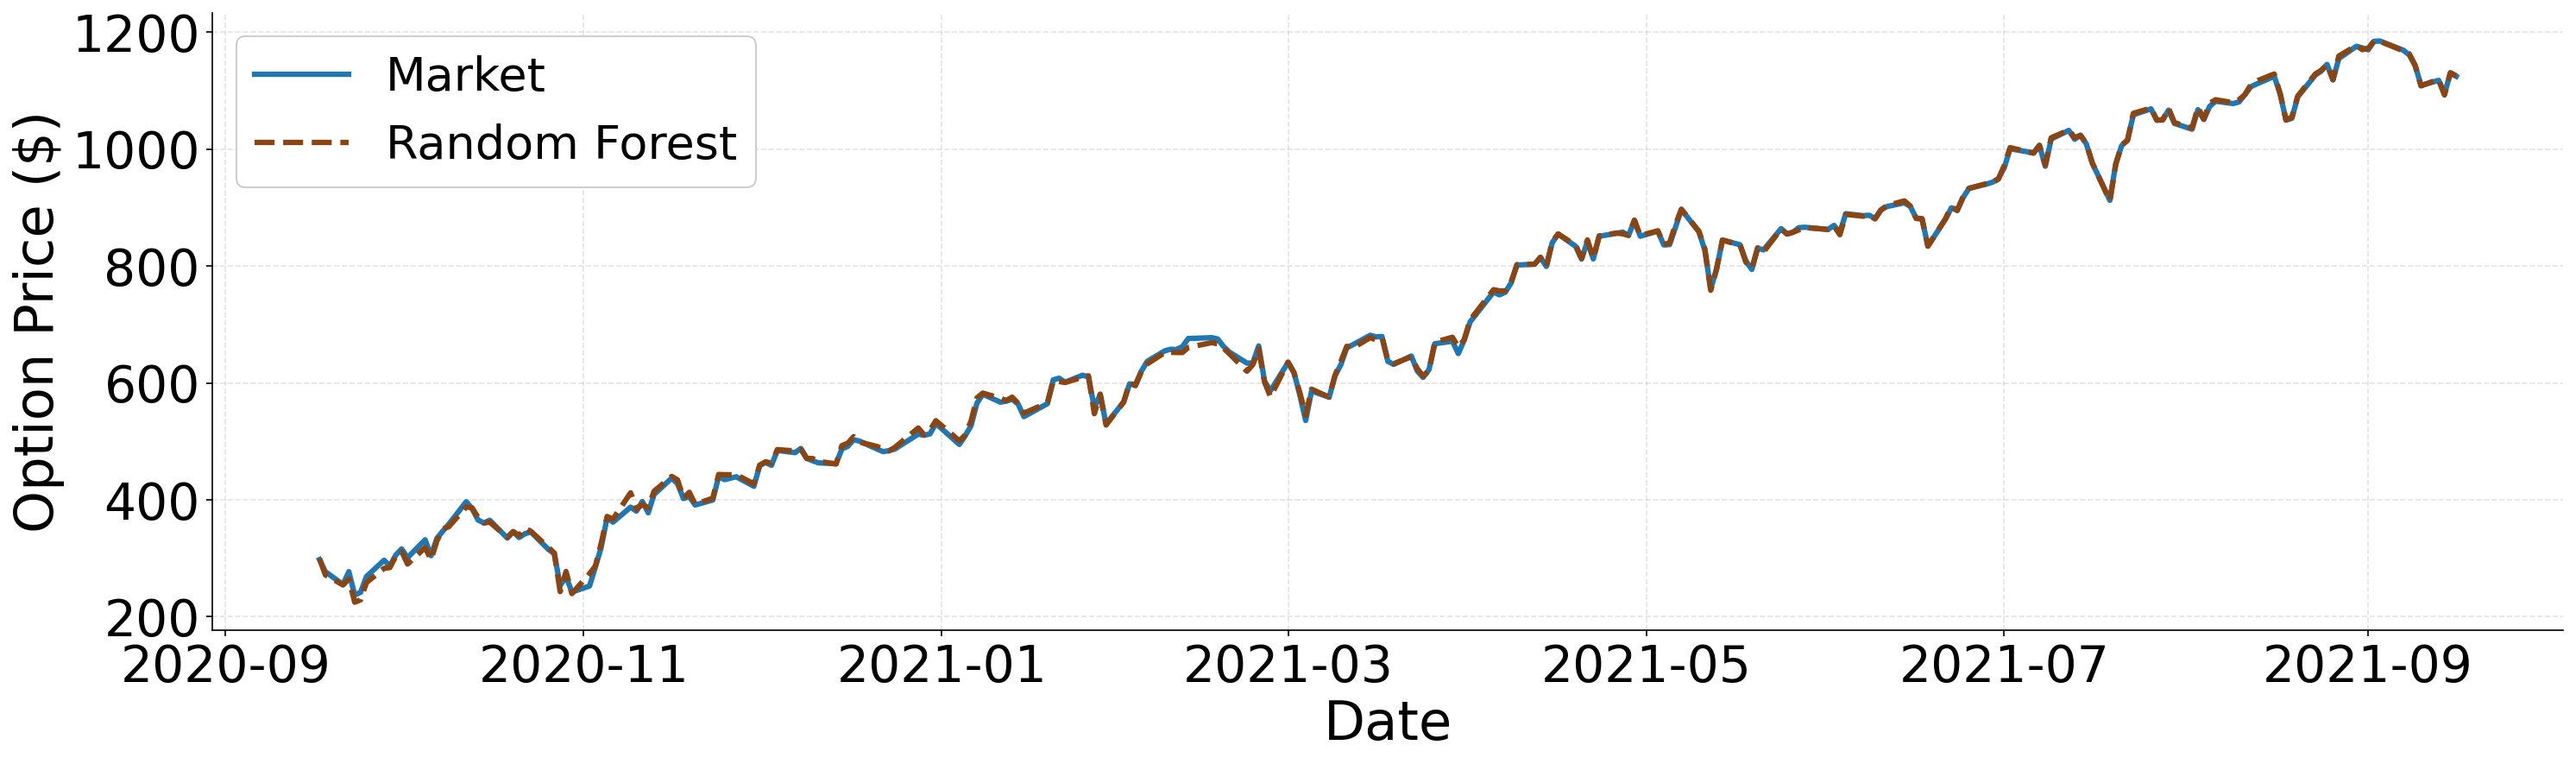

Saved PNG to: C:\Users\samib\OneDrive - Imperial College London\Imperial\Education\Year 4\Masters Project\Code\MastersProject\Results\long option\market_vs_randomforest_longoption.png


In [18]:
# ------------------------------------------------------------------
# Market vs ML model plot (ATM, short-dated test option)
# Copy this cell into each ML notebook; change the FOUR lines below.
# ------------------------------------------------------------------
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ---- change these four for each model ----
MODEL_NAME_PRETTY = "Random Forest"
MODEL_COLOUR      = "#8B4513"      # brown
PRED              = pred_test_final    # whatever the test predictions are called
FILE_TAG          = "randomforest"

# Reference palette for the other four notebooks:
#   XGBoost  -> "#E91E63"  magenta     tag: "xgboost"
#frandomf forest-> "#8B4513"  brown       tag: "lightgbm"
#   FFNN     -> "#B8860B"  goldenrod   tag: "ffnn"
#   LSTM     -> "#000000"  black       tag: "lstm"

save_dir = Path(r"C:\Users\samib\OneDrive - Imperial College London\Imperial\Education\Year 4\Masters Project\Code\MastersProject\Results\long option")
save_dir.mkdir(parents=True, exist_ok=True)

# Align predictions with test_df order (safe if test_df was not re-sorted)
plot_df = test_df.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df["pred"] = pd.Series(PRED).values
plot_df = plot_df.sort_values("date").reset_index(drop=True)

# Figure: wider aspect (20:6) so five fit on one A4 page at 0.95\textwidth
fig, ax = plt.subplots(figsize=(20, 6), dpi=150)

ax.plot(plot_df["date"], plot_df["mid"],
        linewidth=3, label="Market")
ax.plot(plot_df["date"], plot_df["pred"],
        linewidth=3, linestyle="--",
        color=MODEL_COLOUR, label=MODEL_NAME_PRETTY)

ax.set_xlabel("Date", fontsize=30)
ax.set_ylabel("Option Price ($)", fontsize=30)
ax.grid(True, which="major", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=28)

leg = ax.legend(frameon=True, fontsize=26, loc="best")
leg.get_frame().set_alpha(0.95)

plt.tight_layout()

png_path = save_dir / f"market_vs_{FILE_TAG}_longoption.png"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved PNG to: {png_path}")
